# Lab 3 Task 3: QPSK and 8-PSK over the N310 Link

Use this notebook to calculate waveform values, generate the files used by GNU Radio, validate the receiver with synthetic data, and analyze the six real captures.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

def locate_lab_root():
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / "support" / "lab3_tools.py").is_file():
            return base
    raise FileNotFoundError("Open this notebook from its Lab 3 folder.")

LAB_ROOT = locate_lab_root()
sys.path.insert(0, str(LAB_ROOT / "support"))
WORK_DIR = LAB_ROOT / "work"
FIGURE_DIR = WORK_DIR / "figures"
WAVEFORM_DIR = WORK_DIR / "waveforms"
CAPTURE_DIR = WORK_DIR / "captures"
for path in (FIGURE_DIR, WAVEFORM_DIR, CAPTURE_DIR):
    path.mkdir(parents=True, exist_ok=True)
print("Lab root:", LAB_ROOT)

Lab root: /home/sneill/ECE7377


## Waveform calculations

In [4]:
sample_rate_sps = 1_250_000
symbol_rate_baud = 125_000
rolloff = 0.35
span_symbols = 10
baseband_shift_hz = 200_000
guard_symbols = 24
preamble_symbols = 127
payload_symbols = 512
file_periods = 8
transmit_seconds = 20.0
signal_capture_seconds = 8.0
noise_capture_seconds = 1.0

# To Do: derive all counts from the values above.
samples_per_symbol = sample_rate_sps // symbol_rate_baud
raised_cosine_bandwidth_hz = (1 + rolloff) * symbol_rate_baud
lower_edge_hz = baseband_shift_hz - raised_cosine_bandwidth_hz / 2
upper_edge_hz = baseband_shift_hz + raised_cosine_bandwidth_hz / 2
frame_symbol_count = (guard_symbols + preamble_symbols + payload_symbols + guard_symbols)
rrc_tap_count = span_symbols * samples_per_symbol + 1
period_samples = ((frame_symbol_count - 1) * samples_per_symbol + rrc_tap_count)
waveform_file_samples = file_periods * period_samples
waveform_file_bytes = waveform_file_samples * 8
transmit_head_samples = int(transmit_seconds * sample_rate_sps)
signal_capture_samples = int(signal_capture_seconds * sample_rate_sps)
signal_capture_bytes = signal_capture_samples * 8
noise_capture_samples = int(noise_capture_seconds * sample_rate_sps)
noise_capture_bytes = noise_capture_samples * 8

In [5]:
expected = {
    "samples_per_symbol": 10,
    "frame_symbol_count": 687,
    "rrc_tap_count": 101,
    "period_samples": 6961,
    "waveform_file_samples": 55688,
    "waveform_file_bytes": 445504,
    "transmit_head_samples": 25_000_000,
    "signal_capture_samples": 10_000_000,
    "signal_capture_bytes": 80_000_000,
    "noise_capture_samples": 1_250_000,
    "noise_capture_bytes": 10_000_000,
}
for name, value in expected.items():
    assert globals()[name] == value, f"Check {name}"
print(f"Ideal shifted band: {lower_edge_hz/1e3:.3f} to {upper_edge_hz/1e3:.3f} kHz")
print("Waveform and capture calculations passed.")

Ideal shifted band: 115.625 to 284.375 kHz
Waveform and capture calculations passed.


4-PSK: task3_m4_tx_c64.dat, 445504 bytes, peak 0.100
8-PSK: task3_m8_tx_c64.dat, 445504 bytes, peak 0.100


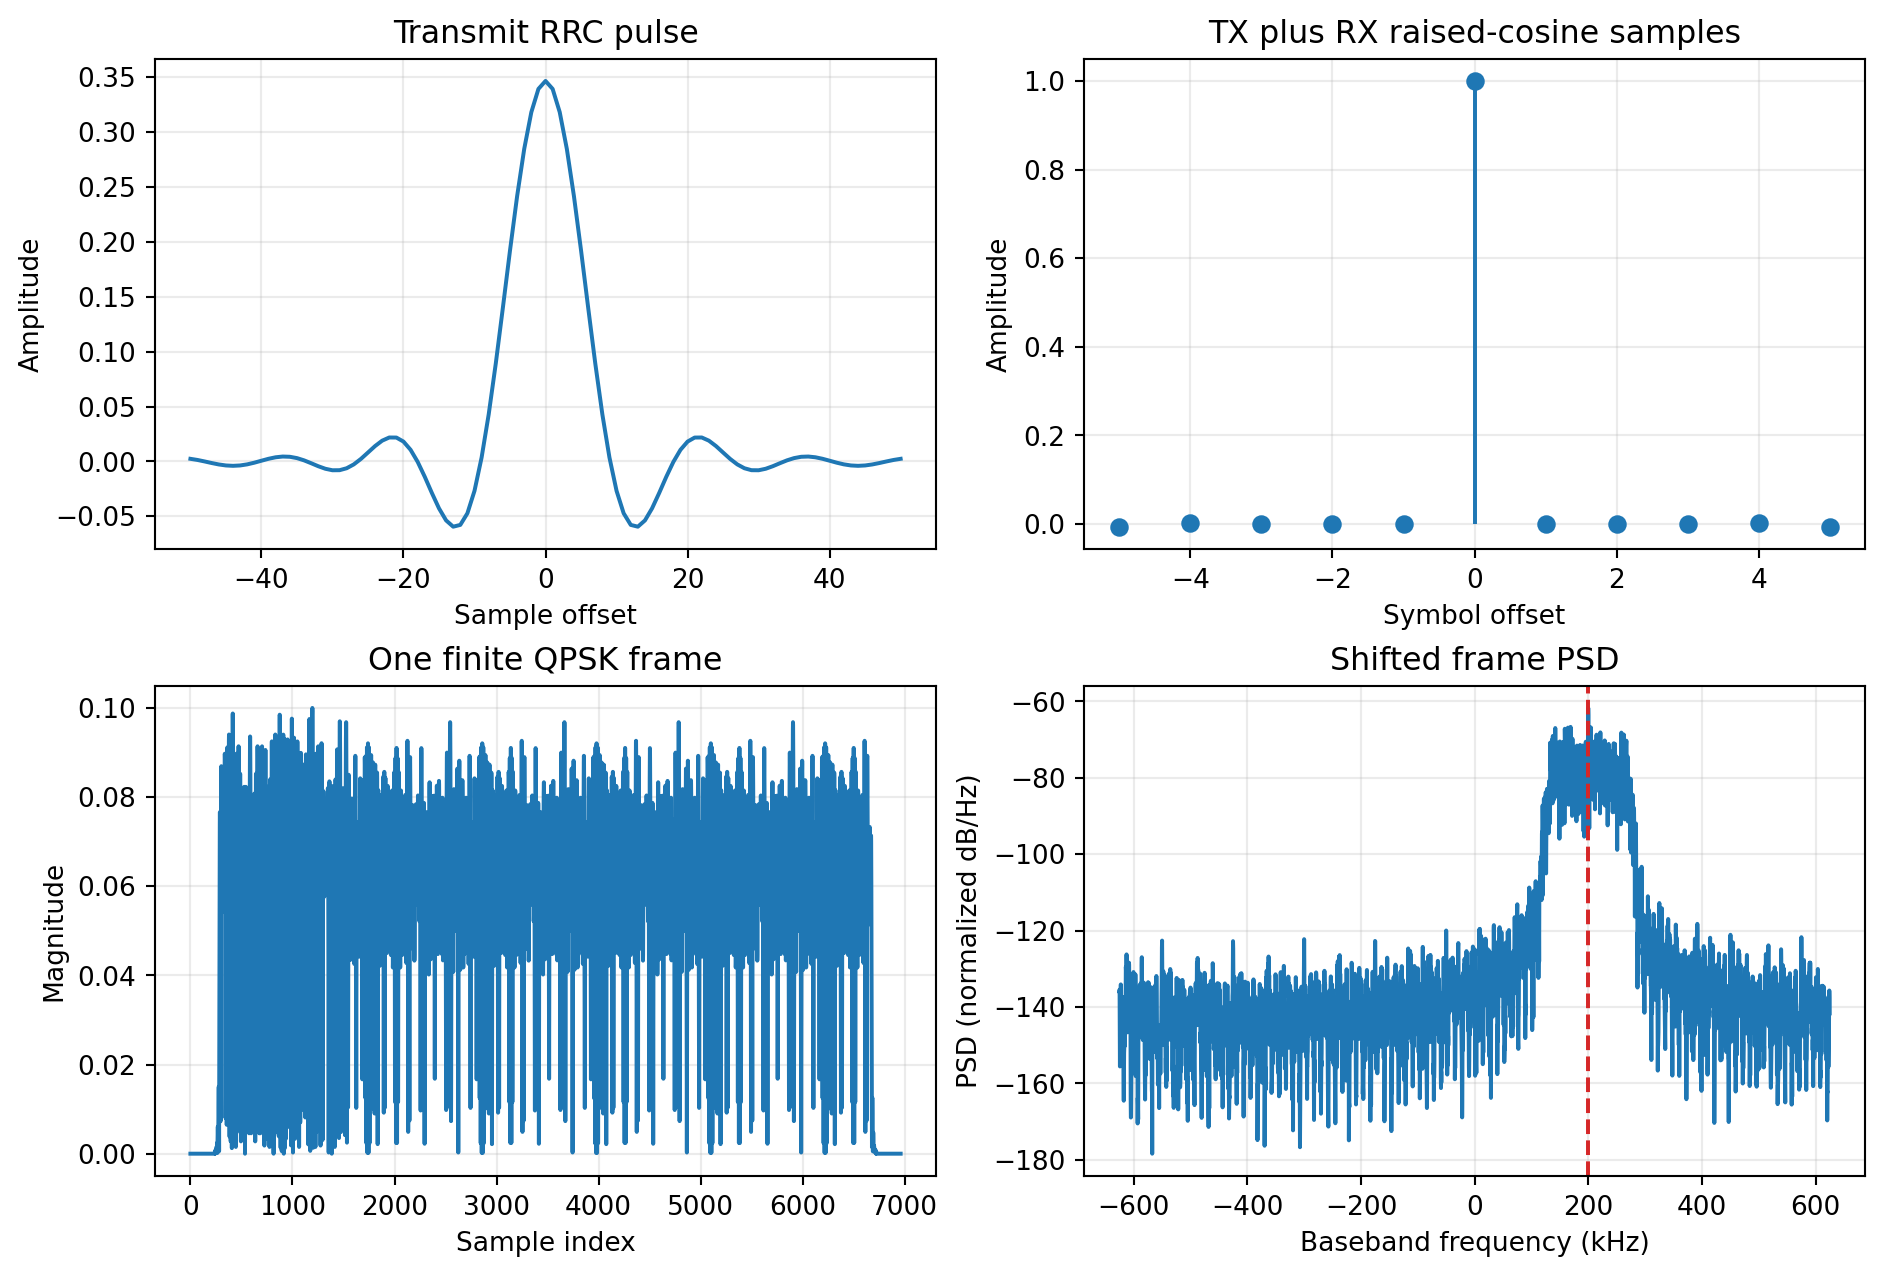

In [6]:
from lab3_tools import (
    analyze_psk_capture, build_psk_frame, make_synthetic_psk_capture,
    plot_synthetic_psk_result, plot_task3_measurements, plot_task3_waveform
)

references = {order: build_psk_frame(order, WAVEFORM_DIR) for order in (4, 8)}
(WAVEFORM_DIR / "task3_message.txt").write_text("ECE7377 LAB3 PYTHON RADIO | \n")
for order, reference in references.items():
    path = reference["waveform_path"]
    print(f"{order}-PSK: {path.name}, {path.stat().st_size} bytes, peak {np.max(np.abs(reference['finite_file'])):.3f}")
waveform_figure = plot_task3_waveform(references[4], FIGURE_DIR)
display(Image(filename=str(waveform_figure)))

## Synthetic receiver check

Run the reference-assisted receiver on a known capture before using RF data. This test isolates receiver logic from radio setup.

True first lag: 5000
Recovered first lag: 5000
True/estimated CFO: 85.000 / 84.997 Hz
SER=0.000000, BER=0.000000, EVM=2.146%
Decoded: ECE7377 LAB3 PYTHON RADIO | 


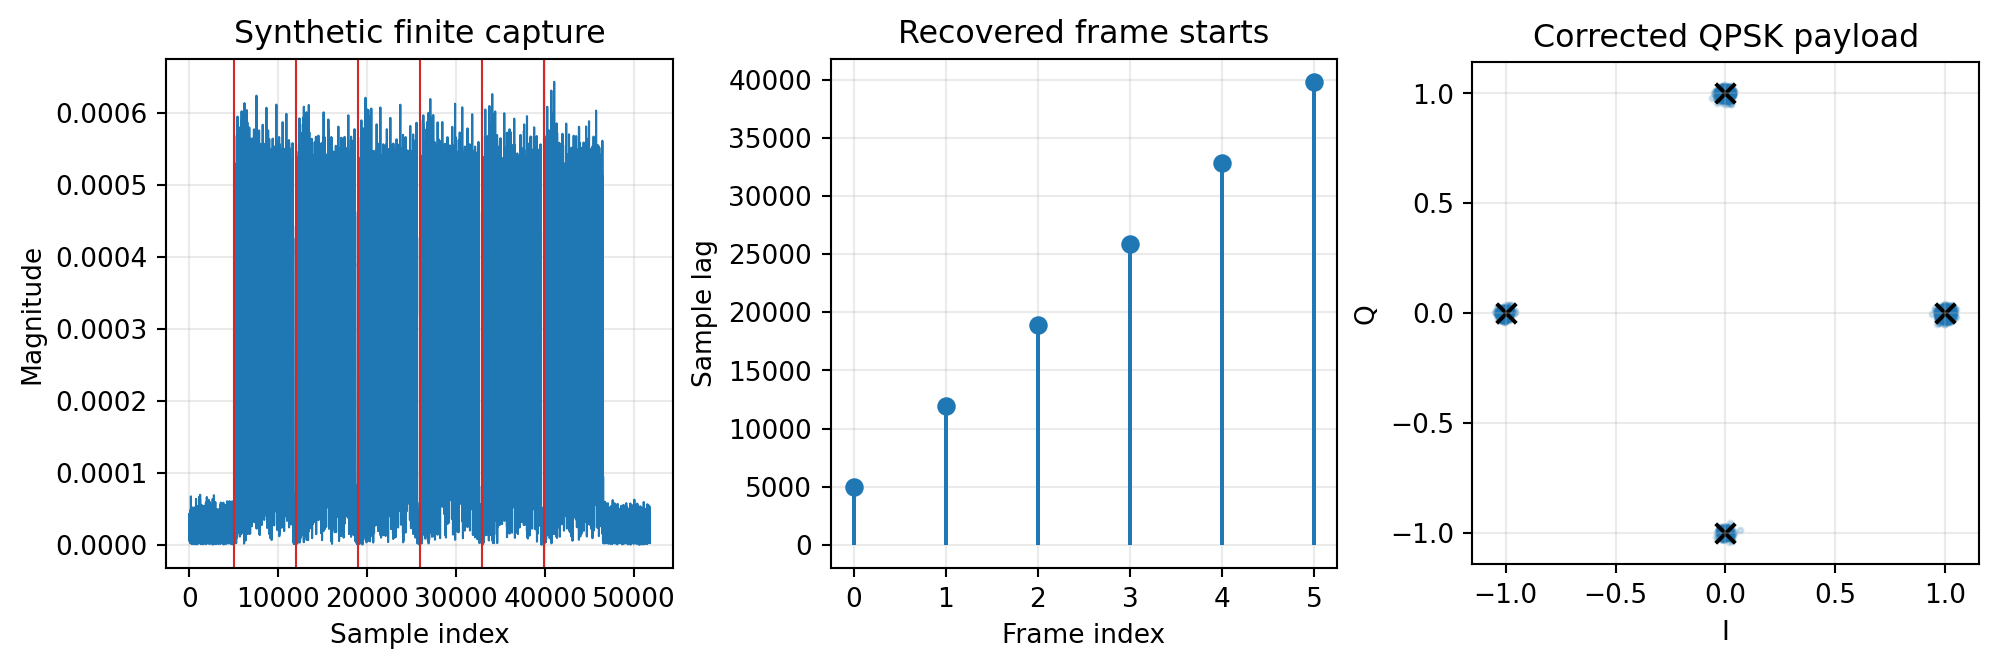

In [7]:
synthetic_dir = WORK_DIR / "synthetic"
synthetic_capture, synthetic_noise, truth = make_synthetic_psk_capture(
    references[4], synthetic_dir
)
synthetic_result = analyze_psk_capture(
    synthetic_capture, synthetic_noise, references[4], maximum_frames=6
)
synthetic_figure = plot_synthetic_psk_result(
    synthetic_capture, synthetic_result, references[4], FIGURE_DIR
)
print("True first lag:", truth["true_lag"])
print("Recovered first lag:", int(synthetic_result["correlation_lags"][0]))
print(f"True/estimated CFO: {truth['true_cfo_hz']:.3f} / {synthetic_result['cfo_hz']:.3f} Hz")
print(f"SER={synthetic_result['ser']:.6f}, BER={synthetic_result['ber']:.6f}, EVM={synthetic_result['evm_percent']:.3f}%")
print("Decoded:", synthetic_result["decoded_prefixes"][0])
display(Image(filename=str(synthetic_figure)))

## GNU Radio capture sequence

Open `flowgraphs/lab3_finite_receiver.grc` on the RX desktop and `flowgraphs/lab3_finite_file_transmitter.grc` on the TX desktop.

1. In each UHD block, enter the assigned `addr=...`, subdevice, and antenna.
2. Verify 2.45 GHz, 1.25 MS/s, one channel, and the intended gain.
3. With the transmitter stopped, set the receiver to 1.0 second and save `task3_noise_c64.dat`.
4. For each modulation and gain, set the receiver to 8.0 seconds and choose a unique output filename.
5. Start the 20.0-second transmitter first, then start the receiver.
6. Confirm 10,000,000 samples and 80,000,000 bytes for every signal record.

The repeated File Source and 20-second finite Head give independently initialized N310 flowgraphs enough overlap. The Head block stops transmission after exactly 25,000,000 samples. No Throttle block is used because UHD controls the stream rate.

## Analyze the real captures

The expected filenames are `task3_m4_gain10_c64.dat`, `task3_m4_gain25_c64.dat`, `task3_m4_gain40_c64.dat`, and the corresponding `m8` files.

In [ ]:
noise_path = CAPTURE_DIR / "task3_noise_c64.dat"
capture_names = [
    f"m{order}_gain{gain}"
    for order in (4, 8)
    for gain in (10, 25, 40)
]
required = [noise_path] + [CAPTURE_DIR / f"task3_{name}_c64.dat" for name in capture_names]
missing = [path for path in required if not path.is_file()]
if missing:
    raise FileNotFoundError("Capture these files before analysis: " + ", ".join(path.name for path in missing))

records = {}
for name in capture_names:
    order = 4 if name.startswith("m4") else 8
    records[name] = analyze_psk_capture(
        CAPTURE_DIR / f"task3_{name}_c64.dat", noise_path, references[order]
    )
    record = records[name]
    print(
        f"{name:11s} SNR={record['snr_db']:6.2f} dB  "
        f"EVM={record['evm_percent']:6.2f}%  SER={record['ser']:.6f}  "
        f"BER={record['ber']:.6f}  CFO={record['cfo_hz']:7.2f} Hz"
    )

In [ ]:
constellation_figure, metrics_figure = plot_task3_measurements(records, FIGURE_DIR)
display(Image(filename=str(constellation_figure)))
display(Image(filename=str(metrics_figure)))
for name, record in records.items():
    print(name, "decoded:", record["decoded_prefixes"][0])

<span style="color:#165696"><b>Report.</b> Include both GRC canvases, both waveform files, noise and six signal records, exact sample counts, GRC settings, SNR, EVM, SER, BER, CFO, maximum magnitude, constellation figures, decoded text, and an explanation of why 8-PSK is more sensitive to angular error.</span>